## Experiment Tutorial: Two Qubits

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration,
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.experiment.experiment import Experiment
from qsopt.core.loss_functions import DetectionMetric

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [ ]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width

interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=list(np.array([2.0, 2.0])*gm),
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 8.0])/inverse_pulse_width) 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0, 0.0]
  Dephasing rate:       [0.0, 0.0]
  Relaxation rate:      [0.0, 0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [ ]:
# Create Circuit with 4 rotation angles

initial_circuit = create_ry_circuit(n_qubits=2,
        theta_values=[0,np.pi/2]) #np.pi/2)
final_circuit = create_ry_circuit(n_qubits=2,
        theta_values=[0,-np.pi/2]) #-np.pi/2)

detection_metric = DetectionMetric(n_qubits=2, detection_criterion = 'max difference')

import optax
optimizer = optax.sgd(learning_rate=1.)

print(initial_circuit)
print(final_circuit)

QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=0.0000)
  1: RY[1](param=1.5708)
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=0.0000)
  1: RY[1](param=-1.5708)


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [ ]:
experiment = Experiment(exp_params, initial_circuit, final_circuit, detection_metric)

## 4. Run Basic Simulation

In [ ]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1, debug=True)

print(callback)


initialize_solvers               :  1.627785
get_measurements                 :  0.000030
get_circuits                     :  1.104203
start_measurement_loop           :  0.000005
start_simulation_with0           :  0.000006
load_cached_parameters0          :  0.000014
start_simulation0                :  0.000196
measurement0:solver_0            :  7.084877
measurement0:measure_0           :  0.141684
returning_simulation0            :  0.000081
start_simulation_no0             :  0.000010
load_cached_parameters0          :  0.000023
start_simulation0                :  0.000210
measurement0:solver_0            :  1.047800
measurement0:measure_0           :  0.000219
returning_simulation0            :  0.000021
compute_probs                    :  0.047622
save_callback                    :  0.001386

Tempo totale di simulazione = 11.05617094039917


MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 0.000000 rad (0.00°)
        param_1: 1.570796 rad (9

## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [ ]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=200,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=5,
    initial_values=[1,0.75,-0.8,-1.7],
    renormalize_grad=False,
    optimizer=optax.adam(learning_rate=0.5)
)


Configuration:
    Max iterations: 200
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: max difference
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.000  rad (57.3°)
        param1.  setup_RY[1]  = 0.750  rad (43.0°)
        param2.  reset_RY[0]  = -0.800 rad (-45.8°)
        param3.  reset_RY[1]  = -1.700 rad (-97.4°)
Step  setup0_RY[0]   setup1_RY[1]   reset0_RY[0]   reset1_RY[1]   Contrast    Grad Norm   Time
---------------------------------------------------------------------------
0     1.000000       0.750000       -0.800000      -1.700000      0.758362    4.46e-01    34.83   
5     2.035238       0.514933       -1.785658      -1.700000      0.892623    3.84e-01    95.27   
10    1.347291       0.667454       -1.687634      -1.700000      0.952187    2.73e-01    99.76   
15    1.458522       1.593085       -1.343798      -1.456994      0.983325    1.27e-01    100.08 

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


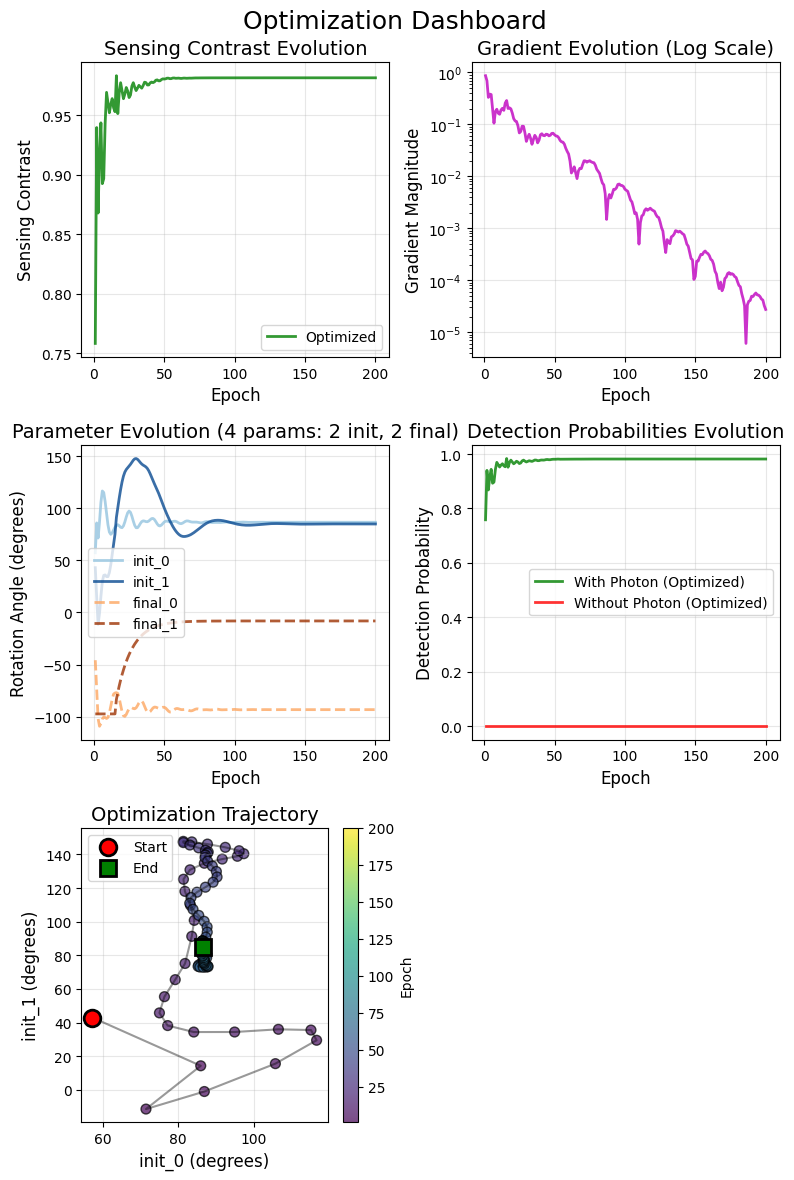

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(8, 12)
)
plt.show()
